In [1]:
from model_v2_w6ms3.My.Encoder_sober import *
from model_v2_w6ms3.My.train_v22_hard_fbmask import *
from model_v2_w6ms3.DataLoader import TempFlowDataset_disp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cfg = {
  "data": {
    "data_root": "../../Data",
    "stats_file": "stats.json",
    "crop_size": [
      352,
      1216
    ],
    "seq_len": 4,
    "center_frame_idx": 10,
    "split": "training",
    "image_folder": "image_2",
    "flow_type": "flow_occ",
    "disp_type": "disp_occ",
    "normalize": True,
    "return_pair_only": False
  },
  "model": {
    "pair_feat_ch": 64,
    "corr_radius": 4,
    "pair_embed_ch": 128,
    "predict_flow_init": True,
    "visual_in_ch": 3,
    "visual_base_ch": 32,
    "visual_out_ch": 64,
    "motion_in_ch": 128,
    "motion_hidden_ch": 128,
    "motion_out_ch": 64,
    "fusion_visual_ch": 64,
    "fusion_motion_ch": 64,
    "fusion_hidden_ch": 128,
    "fusion_out_ch": 128,
    "uno_use_valid_mask": True,
    "uno_hidden_channels": 64,
    "uno_lifting_channels": 128,
    "uno_projection_channels": 128,
    "uno_n_layers": 4,
    "uno_out_channels": [
      64,
      128,
      128,
      64
    ],
    "uno_n_modes": [
      [
        16,
        16
      ],
      [
        12,
        12
      ],
      [
        12,
        12
      ],
      [
        16,
        16
      ]
    ],
    "uno_scalings": [
      [
        1.0,
        1.0
      ],
      [
        0.5,
        0.5
      ],
      [
        2.0,
        2.0
      ],
      [
        1.0,
        1.0
      ]
    ],
    "decoder_in_ch": 128,
    "decoder_hidden_ch": 64,
    "decoder_upsample": 8,
    "decoder_use_prev_flow": True
  },
  "train": {
    "batch_size": 2,
    "num_epochs": 400,
    "lr": 0.0001,
    "weight_decay": 0.0001,
    "num_workers": 0,
    "shuffle": True,
    "pin_memory": True,
    "log_every_n_steps": 10,
    "seed": 42,
    "save_epoch_checkpoints": [
      50,
      100,
      150,
      200
    ]
  },
  "loss": {
    "lambda_temp": 0.03,
    "lambda_smooth": 0.01,
    "lambda_self": 0.1,
    "lambda_edge_weight": 1.0,
    "photo_lambda_l1": 0.15,
    "photo_lambda_ssim": 0.85,
    "photo_lambda_census": 0.3,
    "photo_census_patch": 7,
    "photo_multiframe_reduction": "mean",
    "photo_use_confidence": True,
    "photo_texture_floor": 0.05,
    "photo_robust_beta": 10.0,
    "photo_use_fb_consistency": True,
    "photo_bidirectional": True,
    "fb_alpha": 0.01,
    "fb_beta": 0.5,
    "fb_gamma": 2.0,
    "fb_conf_floor": 0.05,
    "lambda_acc_photo": 0.05,
    "lambda_acc_smooth": 0.0,
    "accum_max_skip": 2,
    "lambda_fb": 0.01,
    "fb_loss_robust_eps": 0.01,
    "photo_use_hard_fb_mask": True,
    "fb_mask_alpha1": 0.01,
    "fb_mask_alpha2": 0.5
  },
  "experiment": {
    "experiment_name": "v22_hard_fbmask",
    "save_dir": "checkpoints",
    "tensorboard_dir": "runs",
    "checkpoint_name": "fullpipeline_v22_latest.pth",
    "best_checkpoint_name": "fullpipeline_v22_best.pth",
    "config_dump_name": "config_v22_hard_fbmask.json"
  }
}

In [3]:
set_seed(cfg["train"]["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = TempFlowDataset_disp(
        root=cfg["data"]["data_root"],
        split=cfg["data"]["split"],
        image_folder=cfg["data"]["image_folder"],
        flow_type=cfg["data"]["flow_type"],
        disp_type=cfg["data"]["disp_type"],
        seq_len=cfg["data"]["seq_len"],
        center_frame_idx=cfg["data"]["center_frame_idx"],
        crop_size=tuple(cfg["data"]["crop_size"]),
        normalize=cfg["data"]["normalize"],
        stats_in=cfg["data"]["stats_file"],
        return_pair_only=cfg["data"]["return_pair_only"],
    )

train_loader = DataLoader(
        dataset,
        batch_size=cfg["train"]["batch_size"],
        shuffle=cfg["train"]["shuffle"],
        num_workers=cfg["train"]["num_workers"],
        pin_memory=cfg["train"]["pin_memory"],
    )

modules = build_modules(cfg, device)
optimizer = torch.optim.AdamW(
        [p for module in modules.values() for p in module.parameters()],
        lr=1e-4,
        weight_decay=1e-4
    )


In [4]:
def forward_pipeline(modules, imgs, valid, uno_use_valid_mask=True):
        pair_encoder = modules['pair_encoder'].to(device)
        pair_out = pair_encoder(imgs)
        #pair_out = modules["pair_encoder"](imgs).to(device)
        pair_feats = pair_out["pair_feats"].to(device)
        flow_inits = pair_out["flow_inits"].to(device)
        corrs = pair_out["corrs"].to(device)

        if flow_inits is None:
            raise RuntimeError("v19 UNO integration requires predict_flow_init=True in the pair encoder.")

        visual_feats = modules["visual_branch"](imgs)
        motion_feats = modules["motion_branch"](pair_feats)
        fused_seq = modules["fusion"](visual_feats, motion_feats)

        valid_ds = None
        if uno_use_valid_mask:
            valid_ds = downsample_valid_mask(valid, fused_seq.shape[-2:])

        uno_in = build_uno_input_2d(fused_seq, flow_inits, valid_mask=valid_ds)
        uno_feat = modules["uno"](uno_in)

        b, tm, _, h, w = fused_seq.shape
        latent_delta = modules["latent_head"](uno_feat, b, tm, h, w)
        refined_seq = fused_seq + latent_delta

        flows, flow_residuals = modules["decoder"](refined_seq, flow_inits=flow_inits)

        return {
            "flows": flows,
            "flow_inits": flow_inits,
            "pair_feats": pair_feats,
            "corrs": corrs,
            "fused_seq": fused_seq,
            "latent_delta": latent_delta,
            "refined_seq": refined_seq,
            "flow_residuals": flow_residuals,
        }

In [5]:
def load_checkpoint(ckpt_path, modules, device, optimizer=None, strict=True):
    ckpt = torch.load(ckpt_path, map_location=device)

    # ---- load module weights ----
    for name, module in modules.items():
        key = f"{name}_state_dict"
        if key in ckpt:
            module.load_state_dict(ckpt[key], strict=strict)
        else:
            print(f"[Warning] Missing key: {key}")

        module.to(device)

    # ---- load optimizer (optional) ----
    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    # ---- metadata ----
    epoch = ckpt.get("epoch", None)
    stats = ckpt.get("stats", None)
    config = ckpt.get("config", None)

    print(f"Loaded checkpoint complete from: {ckpt_path} (epoch={epoch})")

    return {
        "epoch": epoch,
        "stats": stats,
        "config": config,
    }

In [6]:
meta = load_checkpoint(
    ckpt_path="../../model_v2_w6ms3/My/fullpipeline_v22_best.pth",
    modules=modules,
    device=device,
    optimizer=optimizer,   # optional
)
for m in modules.values():
    m.to(device)

Loaded checkpoint complete from: ../../model_v2_w6ms3/My/fullpipeline_v22_best.pth (epoch=387)


In [21]:
# ============================================================
# Data structure for one detected motion region
# ============================================================

@dataclass
class MotionRegion:
    label: int
    area: int
    bbox_xyxy: Tuple[int, int, int, int]         # x1, y1, x2, y2
    rotated_box: np.ndarray                      # 4x2 corners
    center_xy: Tuple[float, float]
    mean_u: float
    mean_v: float
    mean_mag: float
    angle_deg: float
    coherence: float
    confidence: float


# ============================================================
# Utility functions
# ============================================================

def _to_numpy_flow(flow_2hw: torch.Tensor) -> np.ndarray:
    """
    flow_2hw: torch.Tensor [2, H, W]
    return: np.ndarray [H, W, 2]
    """
    flow = flow_2hw.detach().cpu().numpy()
    return np.transpose(flow, (1, 2, 0)).astype(np.float32)


def _normalize_map(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    xmin = np.min(x)
    xmax = np.max(x)
    if xmax - xmin < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - xmin) / (xmax - xmin + eps)


def _flow_to_color(flow_hw2: np.ndarray, clip_mag: Optional[float] = None) -> np.ndarray:
    """
    Convert optical flow [H, W, 2] to HSV/RGB visualization.
    Output: uint8 RGB image [H, W, 3]
    """
    u = flow_hw2[..., 0]
    v = flow_hw2[..., 1]

    mag, ang = cv2.cartToPolar(u, v, angleInDegrees=False)

    if clip_mag is None:
        clip_mag = np.percentile(mag, 99.0)
        clip_mag = max(float(clip_mag), 1e-6)

    mag_norm = np.clip(mag / clip_mag, 0.0, 1.0)

    hsv = np.zeros((flow_hw2.shape[0], flow_hw2.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = ((ang * 180 / np.pi) / 2).astype(np.uint8)  # OpenCV hue range [0,180)
    hsv[..., 1] = 255
    hsv[..., 2] = (mag_norm * 255).astype(np.uint8)

    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return bgr


def _compute_mag_ang(flow_hw2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    u = flow_hw2[..., 0]
    v = flow_hw2[..., 1]
    mag = np.sqrt(u * u + v * v)
    ang = np.arctan2(v, u)
    return mag, ang


def _build_saliency(
    mag: np.ndarray,
    valid_mask: Optional[np.ndarray] = None,
    residual_map: Optional[np.ndarray] = None,
    uncertainty_map: Optional[np.ndarray] = None,
    alpha: float = 1.0,
    beta: float = 0.5,
    gamma: float = 0.5,
) -> np.ndarray:
    """
    Version 0 saliency:
      S = alpha * norm(mag) + beta * norm(residual) - gamma * norm(uncertainty)
    """
    s = alpha * _normalize_map(mag)

    if residual_map is not None:
        s = s + beta * _normalize_map(residual_map)

    if uncertainty_map is not None:
        s = s - gamma * _normalize_map(uncertainty_map)

    if valid_mask is not None:
        s = s * valid_mask.astype(np.float32)

    return s.astype(np.float32)


def _threshold_saliency(
    saliency: np.ndarray,
    valid_mask: Optional[np.ndarray] = None,
    method: str = "percentile",
    percentile: float = 88.0,
    otsu_blur_ksize: int = 5,
    sigma_k: float = 1.0,
) -> np.ndarray:
    """
    Threshold saliency into a binary mask.
    method: 'percentile' | 'otsu' | 'meanstd'
    """
    s = saliency.copy()

    if valid_mask is not None:
        vals = s[valid_mask > 0]
    else:
        vals = s.reshape(-1)

    if vals.size == 0:
        return np.zeros_like(s, dtype=np.uint8)

    if method == "percentile":
        thr = np.percentile(vals, percentile)
        mask = (s > thr).astype(np.uint8)

    elif method == "otsu":
        s8 = (_normalize_map(s) * 255).astype(np.uint8)
        if otsu_blur_ksize > 1:
            s8 = cv2.GaussianBlur(s8, (otsu_blur_ksize, otsu_blur_ksize), 0)
        _, mask = cv2.threshold(s8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        mask = (mask > 0).astype(np.uint8)

    elif method == "meanstd":
        mu = float(vals.mean())
        sigma = float(vals.std())
        thr = mu + sigma_k * sigma
        mask = (s > thr).astype(np.uint8)

    else:
        raise ValueError(f"Unknown threshold method: {method}")

    if valid_mask is not None:
        mask = mask * valid_mask.astype(np.uint8)

    return mask.astype(np.uint8)


def _morphology_cleanup(
    mask: np.ndarray,
    open_ksize: int = 3,
    close_ksize: int = 7,
    dilate_ksize: int = 0,
    erode_ksize: int = 0,
) -> np.ndarray:
    """
    Clean binary mask with morphology.
    """
    out = (mask > 0).astype(np.uint8)

    if open_ksize > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ksize, open_ksize))
        out = cv2.morphologyEx(out, cv2.MORPH_OPEN, k)

    if close_ksize > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
        out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, k)

    if erode_ksize > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_ksize, erode_ksize))
        out = cv2.erode(out, k, iterations=1)

    if dilate_ksize > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_ksize, dilate_ksize))
        out = cv2.dilate(out, k, iterations=1)

    return out.astype(np.uint8)


def _component_mean_flow(flow_hw2: np.ndarray, comp_mask: np.ndarray) -> Tuple[float, float, float]:
    u = flow_hw2[..., 0][comp_mask > 0]
    v = flow_hw2[..., 1][comp_mask > 0]

    if u.size == 0:
        return 0.0, 0.0, 0.0

    mean_u = float(np.mean(u))
    mean_v = float(np.mean(v))
    mean_mag = float(np.sqrt(mean_u ** 2 + mean_v ** 2))
    return mean_u, mean_v, mean_mag


def _component_coherence(flow_hw2: np.ndarray, comp_mask: np.ndarray, eps: float = 1e-6) -> float:
    """
    Coherence in [0,1] approximately.
    1 = vectors inside component align well with their mean vector.
    """
    u = flow_hw2[..., 0][comp_mask > 0]
    v = flow_hw2[..., 1][comp_mask > 0]

    if u.size == 0:
        return 0.0

    fu = np.mean(u)
    fv = np.mean(v)
    mean_norm = np.sqrt(fu * fu + fv * fv) + eps

    diffs = np.sqrt((u - fu) ** 2 + (v - fv) ** 2)
    local_mag = np.sqrt(u * u + v * v)
    denom = np.mean(local_mag) + eps

    score = 1.0 - float(np.mean(diffs) / max(denom, mean_norm, eps))
    return float(np.clip(score, 0.0, 1.0))


def _component_orientation_and_rotated_box(comp_mask: np.ndarray) -> Tuple[np.ndarray, float, Tuple[float, float]]:
    """
    Returns:
        box_pts: [4,2] float32
        angle_deg: angle from minAreaRect
        center_xy: center of rotated rect
    """
    ys, xs = np.where(comp_mask > 0)
    pts = np.stack([xs, ys], axis=1).astype(np.float32)

    if pts.shape[0] < 5:
        # Fallback: simple bounding box
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()
        box_pts = np.array([
            [x1, y1],
            [x2, y1],
            [x2, y2],
            [x1, y2],
        ], dtype=np.float32)
        center_xy = ((x1 + x2) / 2.0, (y1 + y2) / 2.0)
        angle_deg = 0.0
        return box_pts, angle_deg, center_xy

    rect = cv2.minAreaRect(pts)   # ((cx, cy), (w, h), angle)
    box_pts = cv2.boxPoints(rect).astype(np.float32)
    center_xy = (float(rect[0][0]), float(rect[0][1]))
    angle_deg = float(rect[2])
    return box_pts, angle_deg, center_xy


def _component_confidence(mean_mag: float, coherence: float, area: int, img_area: int) -> float:
    """
    A simple heuristic confidence.
    """
    area_ratio = area / max(img_area, 1)
    area_term = np.clip(area_ratio * 20.0, 0.0, 1.0)     # small regions get penalized
    mag_term = np.clip(mean_mag / 5.0, 0.0, 1.0)         # assume flow of ~5 px already meaningful
    conf = 0.45 * coherence + 0.35 * mag_term + 0.20 * area_term
    return float(np.clip(conf, 0.0, 1.0))


# ============================================================
# Core detector
# ============================================================

def detect_motion_regions_v0(
    flow_2hw: torch.Tensor,
    valid_hw: Optional[torch.Tensor] = None,
    residual_hw: Optional[torch.Tensor] = None,
    uncertainty_hw: Optional[torch.Tensor] = None,
    *,
    threshold_method: str = "percentile",
    percentile: float = 88.0,
    sigma_k: float = 1.0,
    open_ksize: int = 3,
    close_ksize: int = 9,
    dilate_ksize: int = 0,
    erode_ksize: int = 0,
    min_area: int = 400,
    max_area_ratio: float = 0.60,
    alpha: float = 1.0,
    beta: float = 0.0,
    gamma: float = 0.0,
) -> Dict:
    """
    Detect motion regions from one flow map [2,H,W].
    """
    flow_hw2 = _to_numpy_flow(flow_2hw)
    H, W, _ = flow_hw2.shape
    img_area = H * W

    valid_mask = None
    if valid_hw is not None:
        valid_mask = valid_hw.detach().cpu().numpy().astype(np.uint8)
        valid_mask = (valid_mask > 0).astype(np.uint8)

    residual_map = None
    if residual_hw is not None:
        residual_map = residual_hw.detach().cpu().numpy().astype(np.float32)

    uncertainty_map = None
    if uncertainty_hw is not None:
        uncertainty_map = uncertainty_hw.detach().cpu().numpy().astype(np.float32)

    mag, ang = _compute_mag_ang(flow_hw2)

    saliency = _build_saliency(
        mag=mag,
        valid_mask=valid_mask,
        residual_map=residual_map,
        uncertainty_map=uncertainty_map,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
    )

    raw_mask = _threshold_saliency(
        saliency,
        valid_mask=valid_mask,
        method=threshold_method,
        percentile=percentile,
        sigma_k=sigma_k,
    )

    clean_mask = _morphology_cleanup(
        raw_mask,
        open_ksize=open_ksize,
        close_ksize=close_ksize,
        dilate_ksize=dilate_ksize,
        erode_ksize=erode_ksize,
    )

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(clean_mask, connectivity=8)

    regions: List[MotionRegion] = []
    kept_mask = np.zeros_like(clean_mask, dtype=np.uint8)

    for lab in range(1, num_labels):  # 0 is background
        area = int(stats[lab, cv2.CC_STAT_AREA])

        if area < min_area:
            continue
        if area > max_area_ratio * img_area:
            continue

        x = int(stats[lab, cv2.CC_STAT_LEFT])
        y = int(stats[lab, cv2.CC_STAT_TOP])
        w = int(stats[lab, cv2.CC_STAT_WIDTH])
        h = int(stats[lab, cv2.CC_STAT_HEIGHT])

        comp_mask = (labels == lab).astype(np.uint8)

        mean_u, mean_v, mean_mag = _component_mean_flow(flow_hw2, comp_mask)
        coherence = _component_coherence(flow_hw2, comp_mask)

        rotated_box, angle_deg, center_xy = _component_orientation_and_rotated_box(comp_mask)
        confidence = _component_confidence(mean_mag, coherence, area, img_area)

        kept_mask[comp_mask > 0] = 1

        region = MotionRegion(
            label=lab,
            area=area,
            bbox_xyxy=(x, y, x + w - 1, y + h - 1),
            rotated_box=rotated_box,
            center_xy=center_xy,
            mean_u=mean_u,
            mean_v=mean_v,
            mean_mag=mean_mag,
            angle_deg=angle_deg,
            coherence=coherence,
            confidence=confidence,
        )
        regions.append(region)

    return {
        "flow_hw2": flow_hw2,
        "mag": mag,
        "ang": ang,
        "saliency": saliency,
        "raw_mask": raw_mask,
        "clean_mask": clean_mask,
        "kept_mask": kept_mask,
        "labels": labels,
        "regions": regions,
    }


# ============================================================
# Visualization
# ============================================================

def draw_motion_regions_overlay(
    flow_hw2: np.ndarray,
    regions: List[MotionRegion],
    valid_mask: Optional[np.ndarray] = None,
    show_rotated_box: bool = True,
    show_axis_box: bool = True,
    show_arrow: bool = True,
    show_text: bool = True,
    clip_mag: Optional[float] = None,
) -> np.ndarray:
    """
    Returns an RGB visualization image.
    """
    canvas = _flow_to_color(flow_hw2, clip_mag=clip_mag).copy()

    if valid_mask is not None:
        invalid = (valid_mask == 0)
        # dim invalid area
        canvas[invalid] = (0.35 * canvas[invalid]).astype(np.uint8)

    for r in regions:
        x1, y1, x2, y2 = r.bbox_xyxy

        if show_axis_box:
            cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 255, 255), 2)

        if show_rotated_box:
            pts = r.rotated_box.astype(np.int32).reshape(-1, 1, 2)
            cv2.polylines(canvas, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

        cx, cy = r.center_xy
        cxi, cyi = int(round(cx)), int(round(cy))

        if show_arrow:
            scale = 6.0
            endx = int(round(cx + scale * r.mean_u))
            endy = int(round(cy + scale * r.mean_v))
            cv2.arrowedLine(canvas, (cxi, cyi), (endx, endy), (255, 0, 0), 2, tipLength=0.25)

        cv2.circle(canvas, (cxi, cyi), 3, (255, 255, 0), -1)

        if show_text:
            txt = f"A={r.area} | m={r.mean_mag:.2f} | coh={r.coherence:.2f} | conf={r.confidence:.2f}"
            ty = max(15, y1 - 8)
            cv2.putText(
                canvas, txt, (x1, ty),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA
            )
            cv2.putText(
                canvas, txt, (x1, ty),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA
            )

    return canvas


def visualize_motion_detection_v0(
    batch,
    pred_flows: torch.Tensor,
    sample_idx: int = 0,
    time_idx: Optional[int] = None,
    *,
    threshold_method: str = "percentile",
    percentile: float = 88.0,
    sigma_k: float = 1.0,
    open_ksize: int = 3,
    close_ksize: int = 9,
    min_area: int = 400,
    max_area_ratio: float = 0.60,
    alpha: float = 1.0,
    beta: float = 0.0,
    gamma: float = 0.0,
    figsize_scale: float = 1.0,
):
    """
    Visualize one sample and either:
      - the GT-aligned time_idx from batch["src_idx_in_seq"], or
      - a manually specified time_idx in [0, Tm-1].
    """
    flow_btchw = pred_flows
    assert flow_btchw.ndim == 5, f"Expected [B,Tm,2,H,W], got {flow_btchw.shape}"

    B, Tm, C, H, W = flow_btchw.shape
    assert C == 2

    if time_idx is None:
        if "src_idx_in_seq" not in batch:
            raise ValueError("time_idx is None and batch['src_idx_in_seq'] not found.")
        time_idx = int(batch["src_idx_in_seq"][sample_idx].item())

    assert 0 <= sample_idx < B
    assert 0 <= time_idx < Tm

    flow_2hw = flow_btchw[sample_idx, time_idx]

    valid_hw = None
    if "valid" in batch and batch["valid"] is not None:
        valid_hw = batch["valid"][sample_idx]

    result = detect_motion_regions_v0(
        flow_2hw=flow_2hw,
        valid_hw=valid_hw,
        threshold_method=threshold_method,
        percentile=percentile,
        sigma_k=sigma_k,
        open_ksize=open_ksize,
        close_ksize=close_ksize,
        min_area=min_area,
        max_area_ratio=max_area_ratio,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
    )

    valid_np = None if valid_hw is None else valid_hw.detach().cpu().numpy().astype(np.uint8)
    overlay = draw_motion_regions_overlay(
        result["flow_hw2"],
        result["regions"],
        valid_mask=valid_np,
    )

    flow_rgb = _flow_to_color(result["flow_hw2"])
    sal = result["saliency"]
    raw_mask = result["raw_mask"]
    clean_mask = result["clean_mask"]
    kept_mask = result["kept_mask"]

    plt.figure(figsize=(18 * figsize_scale, 10 * figsize_scale))

    plt.subplot(2, 3, 1)
    plt.imshow(flow_rgb)
    plt.title(f"Flow Visualization | sample={sample_idx}, t={time_idx}")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(sal, cmap="magma")
    plt.title("Saliency")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(raw_mask, cmap="gray")
    plt.title("Raw Threshold Mask")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Morphology Cleaned Mask")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(kept_mask, cmap="gray")
    plt.title("Kept Connected Components")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(overlay)
    plt.title(f"Detected Regions: {len(result['regions'])}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"[sample={sample_idx}, t={time_idx}] detected {len(result['regions'])} regions")
    for i, r in enumerate(result["regions"]):
        print(
            f"  region {i:02d} | area={r.area:5d} | "
            f"bbox={r.bbox_xyxy} | "
            f"mean_uv=({r.mean_u:.2f}, {r.mean_v:.2f}) | "
            f"mean_mag={r.mean_mag:.2f} | "
            f"coh={r.coherence:.3f} | conf={r.confidence:.3f}"
        )

    return result


# ============================================================
# Convenience: run over all 3 decoded flows of one sample
# ============================================================

def visualize_motion_detection_all_t_v0(
    batch,
    pred_flows: torch.Tensor,
    sample_idx: int = 0,
    *,
    threshold_method: str = "percentile",
    percentile: float = 88.0,
    sigma_k: float = 1.0,
    open_ksize: int = 3,
    close_ksize: int = 9,
    min_area: int = 400,
    max_area_ratio: float = 0.60,
    alpha: float = 1.0,
    beta: float = 0.0,
    gamma: float = 0.0,
):
    """
    Visualize all predicted flow steps t=0..Tm-1 for one sample.
    """
    B, Tm, C, H, W = pred_flows.shape
    assert 0 <= sample_idx < B

    results = []
    for t in range(Tm):
        print("=" * 80)
        print(f"sample={sample_idx}, time_idx={t}")
        result = visualize_motion_detection_v0(
            batch=batch,
            pred_flows=pred_flows,
            sample_idx=sample_idx,
            time_idx=t,
            threshold_method=threshold_method,
            percentile=percentile,
            sigma_k=sigma_k,
            open_ksize=open_ksize,
            close_ksize=close_ksize,
            min_area=min_area,
            max_area_ratio=max_area_ratio,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
        )
        results.append(result)

    return results

sample=0, time_idx=0


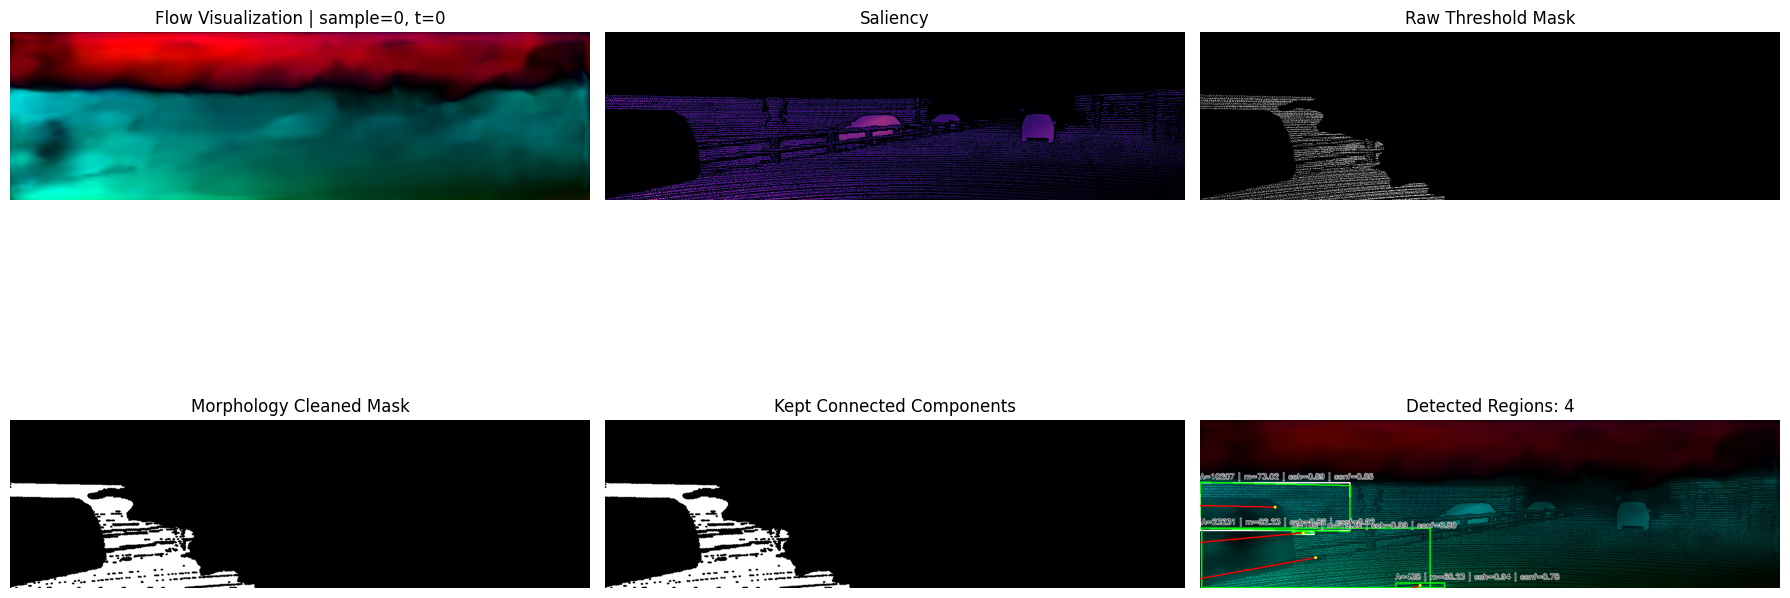

[sample=0, t=0] detected 4 regions
  region 00 | area=10207 | bbox=(0, 131, 314, 231) | mean_uv=(-73.00, -1.51) | mean_mag=73.02 | coh=0.891 | conf=0.846
  region 01 | area=23231 | bbox=(3, 226, 482, 351) | mean_uv=(-80.94, 14.54) | mean_mag=82.23 | coh=0.818 | conf=0.918
  region 02 | area=  146 | bbox=(194, 233, 239, 239) | mean_uv=(-79.01, 7.48) | mean_mag=79.36 | coh=0.988 | conf=0.796
  region 03 | area=  438 | bbox=(410, 341, 512, 351) | mean_uv=(-63.92, 23.85) | mean_mag=68.23 | coh=0.937 | conf=0.776
sample=0, time_idx=1


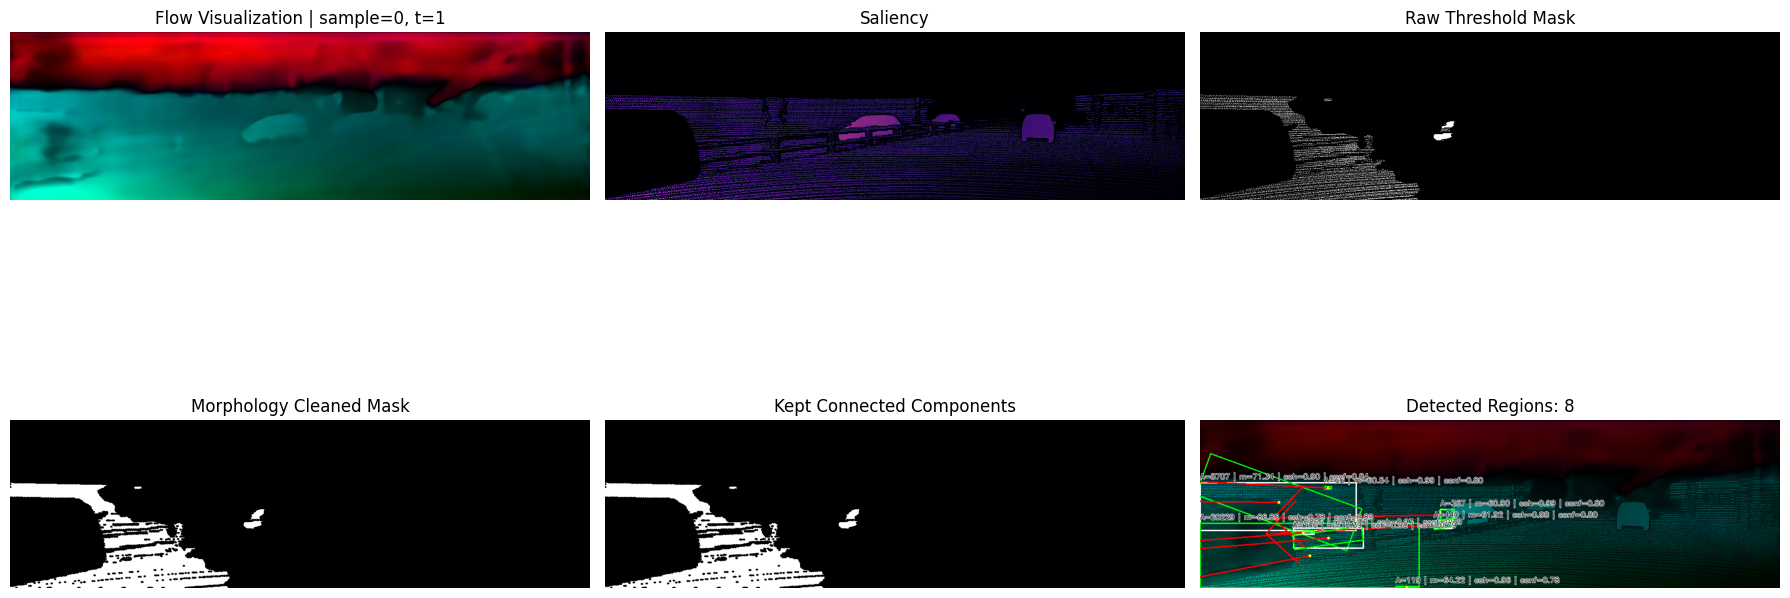

[sample=0, t=1] detected 8 regions
  region 00 | area= 8707 | bbox=(0, 131, 327, 231) | mean_uv=(-71.33, -0.70) | mean_mag=71.34 | coh=0.897 | conf=0.835
  region 01 | area=   65 | bbox=(260, 139, 275, 144) | mean_uv=(-60.46, -2.95) | mean_mag=60.54 | coh=0.995 | conf=0.798
  region 02 | area=  367 | bbox=(504, 187, 532, 209) | mean_uv=(-60.89, 1.26) | mean_mag=60.90 | coh=0.986 | conf=0.797
  region 03 | area=  440 | bbox=(490, 211, 528, 227) | mean_uv=(-61.84, 3.20) | mean_mag=61.92 | coh=0.984 | conf=0.797
  region 04 | area=20229 | bbox=(0, 216, 459, 351) | mean_uv=(-85.28, 16.44) | mean_mag=86.85 | coh=0.776 | conf=0.888
  region 05 | area= 2865 | bbox=(196, 226, 342, 268) | mean_uv=(-71.78, 5.85) | mean_mag=72.02 | coh=0.927 | conf=0.794
  region 06 | area=  146 | bbox=(194, 233, 239, 239) | mean_uv=(-78.17, 5.86) | mean_mag=78.39 | coh=0.983 | conf=0.794
  region 07 | area=  119 | bbox=(410, 348, 456, 351) | mean_uv=(-60.07, 22.72) | mean_mag=64.22 | coh=0.961 | conf=0.784
sampl

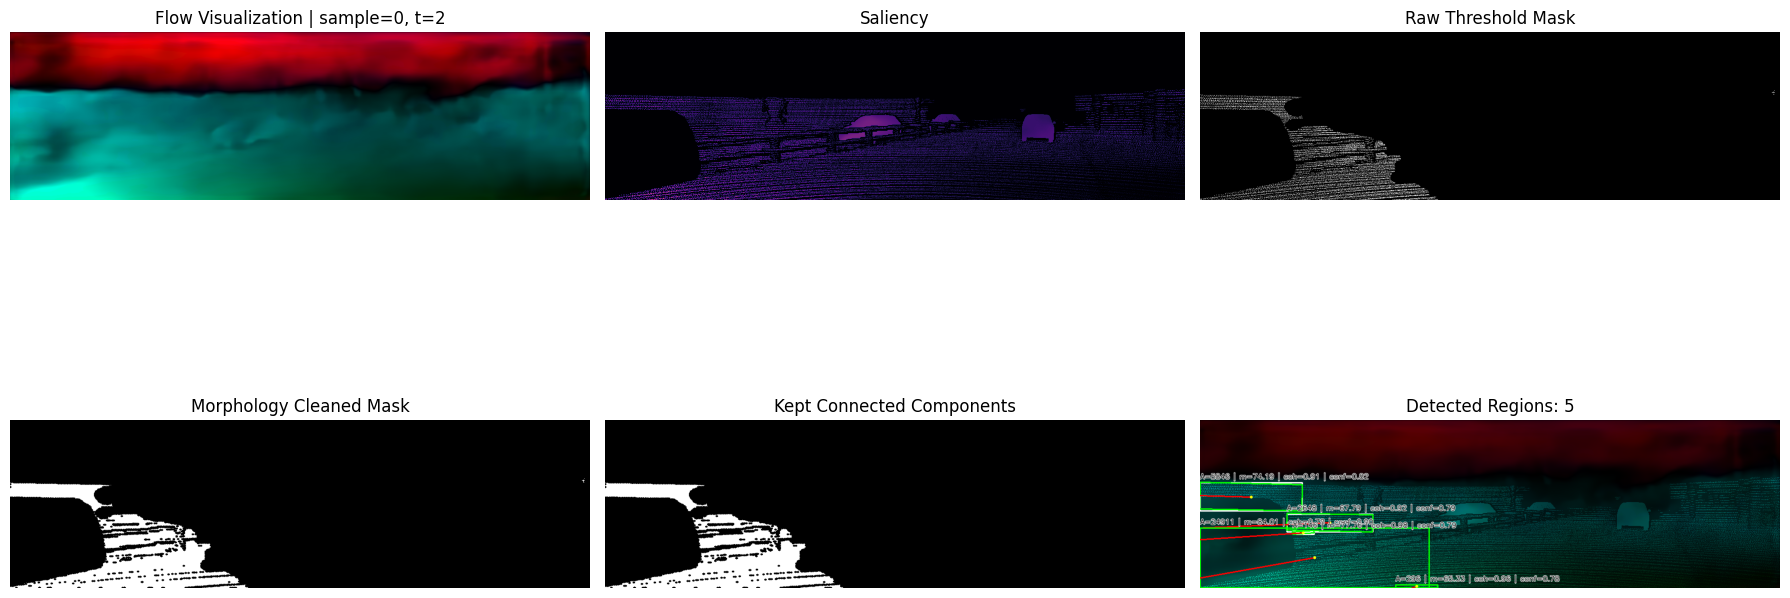

[sample=0, t=2] detected 5 regions
  region 00 | area= 5846 | bbox=(0, 131, 214, 190) | mean_uv=(-74.17, -2.00) | mean_mag=74.19 | coh=0.913 | conf=0.816
  region 01 | area= 2648 | bbox=(182, 197, 362, 234) | mean_uv=(-67.73, 2.73) | mean_mag=67.79 | coh=0.923 | conf=0.790
  region 02 | area=24911 | bbox=(0, 226, 480, 351) | mean_uv=(-82.75, 14.53) | mean_mag=84.01 | coh=0.778 | conf=0.900
  region 03 | area=  146 | bbox=(194, 233, 239, 239) | mean_uv=(-77.58, 5.32) | mean_mag=77.76 | coh=0.985 | conf=0.794
  region 04 | area=  296 | bbox=(410, 345, 498, 351) | mean_uv=(-61.10, 23.11) | mean_mag=65.33 | coh=0.959 | conf=0.784


In [22]:
batch = next(iter(train_loader))
out = forward_pipeline(modules=modules, imgs=batch["imgs"].to(device), valid=batch["valid"].to(device))
pred_flows = out['flows']


results_all = visualize_motion_detection_all_t_v0(
    batch=batch,
    pred_flows=pred_flows,
    sample_idx=0,
    threshold_method="percentile",
    percentile=85.0,
    open_ksize=0,
    close_ksize=5,
    min_area=50,
    max_area_ratio=0.80,
)



{'loss': 1.6420972347259521, 'loss_bce': 0.7207002639770508, 'loss_dice': 0.9386276006698608, 'loss_align': -0.17230579257011414, 'pseudo_iou': 0.0027798227965831757}


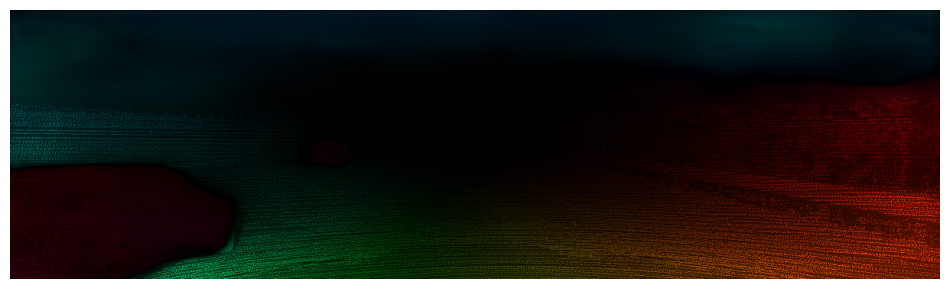

In [14]:
def flow_mag_ang(flow_2hw: torch.Tensor, eps: float = 1e-8):
    """
    flow_2hw: [B,2,H,W]
    returns:
        mag: [B,1,H,W]
        ang: [B,1,H,W]
    """
    u = flow_2hw[:, 0:1]
    v = flow_2hw[:, 1:2]
    mag = torch.sqrt(u * u + v * v + eps)
    ang = torch.atan2(v, u)
    return mag, ang

def charbonnier(x: torch.Tensor, eps: float = 1e-3):
    return torch.sqrt(x * x + eps * eps)

def photometric_residual_map(
    img_src: torch.Tensor,
    img_tgt: torch.Tensor,
    pred_flow: torch.Tensor,
    valid:torch.Tensor = None,
    reduction: str = "l1",
) -> torch.Tensor:
    """
    Build a per-pixel photometric residual map, not a scalar loss.
    img_src:   [B,3,H,W]
    img_tgt:   [B,3,H,W]
    pred_flow: [B,2,H,W]
    valid:     [B,H,W] or [B,1,H,W] or None

    returns:
        residual: [B,1,H,W]
    """
    warped_src = warp_image_with_flow(img_src, pred_flow)

    if reduction == "l1":
        res = torch.mean(torch.abs(warped_src - img_tgt), dim=1, keepdim=True)
    elif reduction == "charb":
        res = torch.mean(charbonnier(warped_src - img_tgt), dim=1, keepdim=True)
    else:
        raise ValueError(f"Unknown reduction={reduction}")

    if valid is not None:
        if valid.ndim == 3:
            valid = valid.unsqueeze(1)
        res = res * valid.float()

    return res

def warp_image_with_flow(img: torch.Tensor, flow: torch.Tensor) -> torch.Tensor:
    """
    img:  [B,3,H,W]
    flow: [B,2,H,W]  (pixel displacement, x/y)
    returns warped image sampled from img using flow
    """
    B, C, H, W = img.shape
    device = img.device

    yy, xx = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing="ij"
    )
    xx = xx.float()[None, None].expand(B, -1, -1, -1)  # [B,1,H,W]
    yy = yy.float()[None, None].expand(B, -1, -1, -1)

    grid_x = xx + flow[:, 0:1]
    grid_y = yy + flow[:, 1:2]

    # normalize to [-1,1]
    grid_x = 2.0 * grid_x / max(W - 1, 1) - 1.0
    grid_y = 2.0 * grid_y / max(H - 1, 1) - 1.0

    grid = torch.cat([grid_x, grid_y], dim=1)          # [B,2,H,W]
    grid = grid.permute(0, 2, 3, 1)                    # [B,H,W,2]

    warped = F.grid_sample(
        img, grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True
    )
    return warped

def pseudo_masks_from_v0_batch(
    pred_flow_btchw: torch.Tensor,
    valid_bhw: Optional[torch.Tensor] = None,
    *,
    threshold_method: str = "percentile",
    percentile: float = 88.0,
    sigma_k: float = 1.0,
    open_ksize: int = 3,
    close_ksize: int = 9,
    min_area: int = 400,
    max_area_ratio: float = 0.60,
    alpha: float = 1.0,
    beta: float = 0.0,
    gamma: float = 0.0,
) -> torch.Tensor:
    """
    pred_flow_btchw: [B,2,H,W]
    valid_bhw:       [B,H,W] or None

    returns:
        pseudo_mask: [B,1,H,W] float in {0,1}
    """
    B, C, H, W = pred_flow_btchw.shape
    assert C == 2

    masks = []
    for b in range(B):
        valid_hw = None if valid_bhw is None else valid_bhw[b]

        result = detect_motion_regions_v0(
            flow_2hw=pred_flow_btchw[b],
            valid_hw=valid_hw,
            threshold_method=threshold_method,
            percentile=percentile,
            sigma_k=sigma_k,
            open_ksize=open_ksize,
            close_ksize=close_ksize,
            min_area=min_area,
            max_area_ratio=max_area_ratio,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
        )
        m = torch.from_numpy(result["kept_mask"]).float().unsqueeze(0)  # [1,H,W]
        masks.append(m)

    return torch.stack(masks, dim=0)  # [B,1,H,W]

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)
    
class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))
    
class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        dy = skip.shape[-2] - x.shape[-2]
        dx = skip.shape[-1] - x.shape[-1]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)
    
class MotionMaskUNet(nn.Module):
    def __init__(self, in_ch=7, base_ch=32):
        super().__init__()
        self.inc = DoubleConv(in_ch, base_ch)
        self.down1 = Down(base_ch, base_ch * 2)
        self.down2 = Down(base_ch * 2, base_ch * 4)
        self.down3 = Down(base_ch * 4, base_ch * 8)

        self.up1 = Up(base_ch * 8, base_ch * 4, base_ch * 4)
        self.up2 = Up(base_ch * 4, base_ch * 2, base_ch * 2)
        self.up3 = Up(base_ch * 2, base_ch, base_ch)

        self.out_head = nn.Conv2d(base_ch, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        y = self.up1(x4, x3)
        y = self.up2(y, x2)
        y = self.up3(y, x1)

        logits = self.out_head(y)
        return logits

def masked_bce_with_logits(logits, target, valid=None):
    """
    logits,target: [B,1,H,W]
    valid: [B,1,H,W] or [B,H,W] or None
    """
    loss = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    if valid is not None:
        if valid.ndim == 3:
            valid = valid.unsqueeze(1)
        loss = loss * valid.float()
        return loss.sum() / valid.sum().clamp_min(1.0)
    return loss.mean()

def masked_dice_loss(logits, target, valid=None, eps=1e-6):
    probs = torch.sigmoid(logits)

    if valid is not None:
        if valid.ndim == 3:
            valid = valid.unsqueeze(1)
        probs = probs * valid.float()
        target = target * valid.float()

    inter = (probs * target).sum(dim=(1, 2, 3))
    denom = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * inter + eps) / (denom + eps)
    return 1.0 - dice.mean()

def mask_motion_alignment_loss(logits, mag, valid=None):
    """
    Encourage predicted mask to cover strong-motion regions.
    mag: [B,1,H,W]
    """
    probs = torch.sigmoid(logits)
    mag_norm = mag / mag.amax(dim=(2,3), keepdim=True).clamp_min(1e-6)

    if valid is not None:
        if valid.ndim == 3:
            valid = valid.unsqueeze(1)
        probs = probs * valid.float()
        mag_norm = mag_norm.to(device) * valid.to(device).float()

    # maximize mean magnitude inside predicted mask => minimize negative value
    numer = (probs * mag_norm).sum(dim=(1,2,3))
    denom = probs.sum(dim=(1,2,3)).clamp_min(1e-6)
    return -(numer / denom).mean()

def v1_mask_loss(
    logits,
    pseudo_mask,
    mag,
    valid=None,
    lambda_bce=1.0,
    lambda_dice=1.0,
    lambda_align=0.1,
):
    valid = valid.to(device)
    loss_bce = masked_bce_with_logits(logits, pseudo_mask, valid=valid)
    loss_dice = masked_dice_loss(logits, pseudo_mask, valid=valid)
    loss_align = mask_motion_alignment_loss(logits, mag, valid=valid)

    total = lambda_bce * loss_bce + lambda_dice * loss_dice + lambda_align * loss_align
    return {
        "loss": total,
        "loss_bce": loss_bce.detach(),
        "loss_dice": loss_dice.detach(),
        "loss_align": loss_align.detach(),
    }

def build_v1_input_features(
    pred_flow: torch.Tensor,
    valid: Optional[torch.Tensor] = None,
    img_src: Optional[torch.Tensor] = None,
    img_tgt: Optional[torch.Tensor] = None,
    use_photo_residual: bool = True,
    normalize_mag: bool = True,
) -> Dict[str, torch.Tensor]:
    """
    pred_flow: [B,2,H,W]
    valid:     [B,H,W] or [B,1,H,W] or None
    img_src:   [B,3,H,W]
    img_tgt:   [B,3,H,W]

    returns dict with:
        x: [B,C,H,W]
        photo_res: [B,1,H,W] or zeros
        mag: [B,1,H,W]
        ang: [B,1,H,W]
    """
    pred_flow = pred_flow.to(device)
    valid = valid.to(device)
    img_src = img_src.to(device)
    img_tgt = img_tgt.to(device)
    mag, ang = flow_mag_ang(pred_flow)

    if normalize_mag:
        mag_scale = torch.amax(mag.flatten(2), dim=2, keepdim=True).unsqueeze(-1)
        mag_scale = mag_scale.clamp_min(1e-6)
        mag_norm = mag / mag_scale
    else:
        mag_norm = mag

    sin_ang = torch.sin(ang)
    cos_ang = torch.cos(ang)

    feat_list = [
        pred_flow[:, 0:1],   # u
        pred_flow[:, 1:2],   # v
        mag_norm,
        sin_ang,
        cos_ang,
    ]

    if valid is not None:
        if valid.ndim == 3:
            valid_1 = valid.unsqueeze(1).float()
        else:
            valid_1 = valid.detach().cpu().float()
        feat_list.append(valid_1)
    else:
        valid_1 = None

    if use_photo_residual and img_src is not None and img_tgt is not None:
        photo_res = photometric_residual_map(img_src, img_tgt, pred_flow, valid=valid_1)
    else:
        photo_res = pred_flow.new_zeros(pred_flow.shape[0], 1, pred_flow.shape[2], pred_flow.shape[3])

    feat_list.append(photo_res)

    x = torch.cat(feat_list, dim=1)
    return {
        "x": x,
        "photo_res": photo_res,
        "mag": mag,
        "ang": ang,
    }

def build_v1_training_tensors_from_pipeline(
    batch,
    pred_flows: torch.Tensor,
    *,
    use_photo_residual: bool = True,
    pseudo_percentile: float = 88.0,
    pseudo_min_area: int = 400,
    pseudo_close_ksize: int = 9,
) -> Dict[str, torch.Tensor]:
    """
    batch["imgs"]: [B,4,3,H,W]
    batch["valid"]: [B,H,W]
    pred_flows: [B,Tm,2,H,W]

    Flattens over Tm so output tensors become [B*Tm, C, H, W]
    """
    imgs = batch["imgs"]
    valid = batch["valid"] if "valid" in batch else None

    B, Tm, _, H, W = pred_flows.shape
    xs = []
    mags = []
    pseudos = []
    valids = []

    for t in range(Tm):
        pred_t = pred_flows[:, t]                 # [B,2,H,W]
        img_src = imgs[:, t]                      # [B,3,H,W]
        img_tgt = imgs[:, t + 1]                  # [B,3,H,W]

        feat_dict = build_v1_input_features(
            pred_flow=pred_t,
            valid=valid,
            img_src=img_src,
            img_tgt=img_tgt,
            use_photo_residual=use_photo_residual,
        )

        pseudo_t = pseudo_masks_from_v0_batch(
            pred_flow_btchw=pred_t.detach().cpu(),
            valid_bhw=None if valid is None else valid.detach().cpu(),
            threshold_method="percentile",
            percentile=pseudo_percentile,
            open_ksize=3,
            close_ksize=pseudo_close_ksize,
            min_area=pseudo_min_area,
            max_area_ratio=0.60,
            alpha=1.0,
            beta=0.0,
            gamma=0.0,
        ).to(pred_t.device)

        xs.append(feat_dict["x"])
        mags.append(feat_dict["mag"])
        pseudos.append(pseudo_t)
        if valid is not None:
            if valid.ndim == 3:
                valids.append(valid.unsqueeze(1).float())
            else:
                valids.append(valid.float())

    x_all = torch.cat(xs, dim=0)           # [B*Tm,C,H,W]
    mag_all = torch.cat(mags, dim=0)       # [B*Tm,1,H,W]
    pseudo_all = torch.cat(pseudos, dim=0) # [B*Tm,1,H,W]

    if len(valids) > 0:
        valid_all = torch.cat(valids, dim=0)
    else:
        valid_all = None

    return {
        "x": x_all,
        "mag": mag_all,
        "pseudo_mask": pseudo_all,
        "valid": valid_all,
    }

def train_v1_one_step(
    v1_model: nn.Module,
    optimizer: torch.optim.Optimizer,
    batch,
    pred_flows: torch.Tensor,
    *,
    use_photo_residual: bool = True,
    pseudo_percentile: float = 88.0,
    pseudo_min_area: int = 400,
    pseudo_close_ksize: int = 9,
    lambda_bce: float = 1.0,
    lambda_dice: float = 1.0,
    lambda_align: float = 0.1,
):
    v1_model.train()

    pack = build_v1_training_tensors_from_pipeline(
        batch=batch,
        pred_flows=pred_flows,
        use_photo_residual=use_photo_residual,
        pseudo_percentile=pseudo_percentile,
        pseudo_min_area=pseudo_min_area,
        pseudo_close_ksize=pseudo_close_ksize,
    )

    x = pack["x"]
    mag = pack["mag"]
    pseudo_mask = pack["pseudo_mask"]
    valid = pack["valid"].to(device)

    logits = v1_model(x.to(device))

    loss_dict = v1_mask_loss(
        logits=logits,
        pseudo_mask=pseudo_mask,
        mag=mag,
        valid=valid,
        lambda_bce=lambda_bce,
        lambda_dice=lambda_dice,
        lambda_align=lambda_align,
    )

    optimizer.zero_grad(set_to_none=True)
    loss_dict["loss"].backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(logits)
        pred_bin = (probs > 0.5).float()

        if valid is not None:
            inter = (pred_bin * pseudo_mask * valid).sum()
            union = ((pred_bin + pseudo_mask) > 0).float()
            union = (union * valid).sum().clamp_min(1.0)
        else:
            inter = (pred_bin * pseudo_mask).sum()
            union = ((pred_bin + pseudo_mask) > 0).float().sum().clamp_min(1.0)

        iou = inter / union

    return {
        "loss": float(loss_dict["loss"].detach().item()),
        "loss_bce": float(loss_dict["loss_bce"].item()),
        "loss_dice": float(loss_dict["loss_dice"].item()),
        "loss_align": float(loss_dict["loss_align"].item()),
        "pseudo_iou": float(iou.item()),
    }

def detect_motion_regions_v1_from_logits(
    flow_2hw: torch.Tensor,
    mask_logits_1hw: torch.Tensor,
    valid_hw: Optional[torch.Tensor] = None,
    *,
    prob_thresh: float = 0.5,
    open_ksize: int = 3,
    close_ksize: int = 9,
    min_area: int = 400,
    max_area_ratio: float = 0.60,
):
    """
    Reuse V0 geometry extraction, but use V1 predicted mask instead of V0 threshold mask.
    """
    flow_hw2 = _to_numpy_flow(flow_2hw)
    H, W, _ = flow_hw2.shape
    img_area = H * W

    probs = torch.sigmoid(mask_logits_1hw).detach().cpu().numpy()[0]  # [H,W]
    raw_mask = (probs > prob_thresh).astype(np.uint8)

    valid_mask = None
    if valid_hw is not None:
        valid_mask = valid_hw.detach().cpu().numpy().astype(np.uint8)
        valid_mask = (valid_mask > 0).astype(np.uint8)
        raw_mask = raw_mask * valid_mask

    clean_mask = _morphology_cleanup(
        raw_mask,
        open_ksize=open_ksize,
        close_ksize=close_ksize,
    )

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(clean_mask, connectivity=8)

    regions = []
    kept_mask = np.zeros_like(clean_mask, dtype=np.uint8)

    for lab in range(1, num_labels):
        area = int(stats[lab, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        if area > max_area_ratio * img_area:
            continue

        x = int(stats[lab, cv2.CC_STAT_LEFT])
        y = int(stats[lab, cv2.CC_STAT_TOP])
        w = int(stats[lab, cv2.CC_STAT_WIDTH])
        h = int(stats[lab, cv2.CC_STAT_HEIGHT])

        comp_mask = (labels == lab).astype(np.uint8)
        mean_u, mean_v, mean_mag = _component_mean_flow(flow_hw2, comp_mask)
        coherence = _component_coherence(flow_hw2, comp_mask)
        rotated_box, angle_deg, center_xy = _component_orientation_and_rotated_box(comp_mask)
        confidence = _component_confidence(mean_mag, coherence, area, img_area)

        kept_mask[comp_mask > 0] = 1

        regions.append(MotionRegion(
            label=lab,
            area=area,
            bbox_xyxy=(x, y, x + w - 1, y + h - 1),
            rotated_box=rotated_box,
            center_xy=center_xy,
            mean_u=mean_u,
            mean_v=mean_v,
            mean_mag=mean_mag,
            angle_deg=angle_deg,
            coherence=coherence,
            confidence=confidence,
        ))

    return {
        "flow_hw2": flow_hw2,
        "raw_mask": raw_mask,
        "clean_mask": clean_mask,
        "kept_mask": kept_mask,
        "labels": labels,
        "regions": regions,
    }

with torch.no_grad():
    out = forward_pipeline(
        modules=modules,
        imgs=batch['imgs'].to(device),
        valid=batch['valid'].to(device),
    )

pred_flows = out["flows"].to(device)   # [B,Tm,2,H,W]

v1_model = MotionMaskUNet(in_ch=7, base_ch=32).to(device)
optimizer = torch.optim.Adam(v1_model.parameters(), lr=1e-3)

stats = train_v1_one_step(
    v1_model=v1_model,
    optimizer=optimizer,
    batch=batch,
    pred_flows=pred_flows,
    use_photo_residual=True,
    pseudo_percentile=88.0,
    pseudo_min_area=400,
    pseudo_close_ksize=9,
    lambda_bce=1.0,
    lambda_dice=1.0,
    lambda_align=0.1,
)
print(stats)

sample_idx = 0
t = 0

pred_t = pred_flows[sample_idx:sample_idx+1, t]       # [1,2,H,W]
img_src = batch["imgs"][sample_idx:sample_idx+1, t].to(device)
img_tgt = batch["imgs"][sample_idx:sample_idx+1, t+1].to(device)
valid_1 = batch["valid"][sample_idx:sample_idx+1].to(device)

feat = build_v1_input_features(
    pred_flow=pred_t,
    valid=valid_1,
    img_src=img_src,
    img_tgt=img_tgt,
    use_photo_residual=True,
)

with torch.no_grad():
    mask_logits = v1_model(feat["x"])  # [1,1,H,W]

result_v1 = detect_motion_regions_v1_from_logits(
    flow_2hw=pred_t[0],
    mask_logits_1hw=mask_logits[0],
    valid_hw=valid_1[0],
    prob_thresh=0.5,
    open_ksize=3,
    close_ksize=9,
    min_area=400,
)

overlay = draw_motion_regions_overlay(
    result_v1["flow_hw2"],
    result_v1["regions"],
    valid_mask=valid_1[0].detach().cpu().numpy().astype(np.uint8),
)
plt.figure(figsize=(12,5))
plt.imshow(overlay)
plt.axis("off")
plt.show()